# Notebook 0: Configuración, descarga, y muestra de datasets de validación

Este notebook consolida la descarga, carga y primera inspección visual de cuatro datasets de series temporales utilizados como base experimental. El objetivo es dejar una colección reproducible para posteriores pruebas de enrutamiento, detección de anomalías, imputación de huecos, predicciones a futuro y pruebas de integración univariante y multivariante.

## Índice de contenidos

1. [Alumbrado Público Regular](#alumbrado-publico)
2. [Alumbrado Público Irregular](#alumbrado-publico-tipo)
3. [ETT (Electricity Transformer Temperature)](#ett-electricity-transformer-temperature)
4. [Beijing Multi-Site Air-Quality](#beijing-multi-site-air-quality)
5. [PeMS Traffic](#pems-traffic)

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import tsdb

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

os.makedirs('datasets', exist_ok=True)

def plot_stacked(df, columns, title, sample_size=1000, colors=None, figsize=None):
    sample = df if sample_size is None else df.iloc[:sample_size]
    if sample.empty:
        raise ValueError('No hay datos para graficar con la seleccion actual.')

    colors = colors or plt.rcParams['axes.prop_cycle'].by_key().get('color', ['#1f77b4'])
    if figsize is None:
        figsize = (12, 4 * len(columns))

    fig, axes = plt.subplots(nrows=len(columns), sharex=True, figsize=figsize)
    if len(columns) == 1:
        axes = [axes]

    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.995)
    for idx, (ax, column) in enumerate(zip(axes, columns)):
        color = colors[idx % len(colors)]
        sample[column].plot(ax=ax, color=color, linewidth=1.2)
        ax.set_ylabel(column)
        ax.set_xlabel('')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[-1].set_xlabel(sample.index.name or 'timestamp')
    plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.98))
    plt.show()

<a id="alumbrado-publico"></a>
## 1. Alumbrado público regular

Serie univariante privada de un cuadro de alumbrado público durante el año 2025, que ejemplifica un comportamiento extremadamente regular, cíclico y con baja complejidad

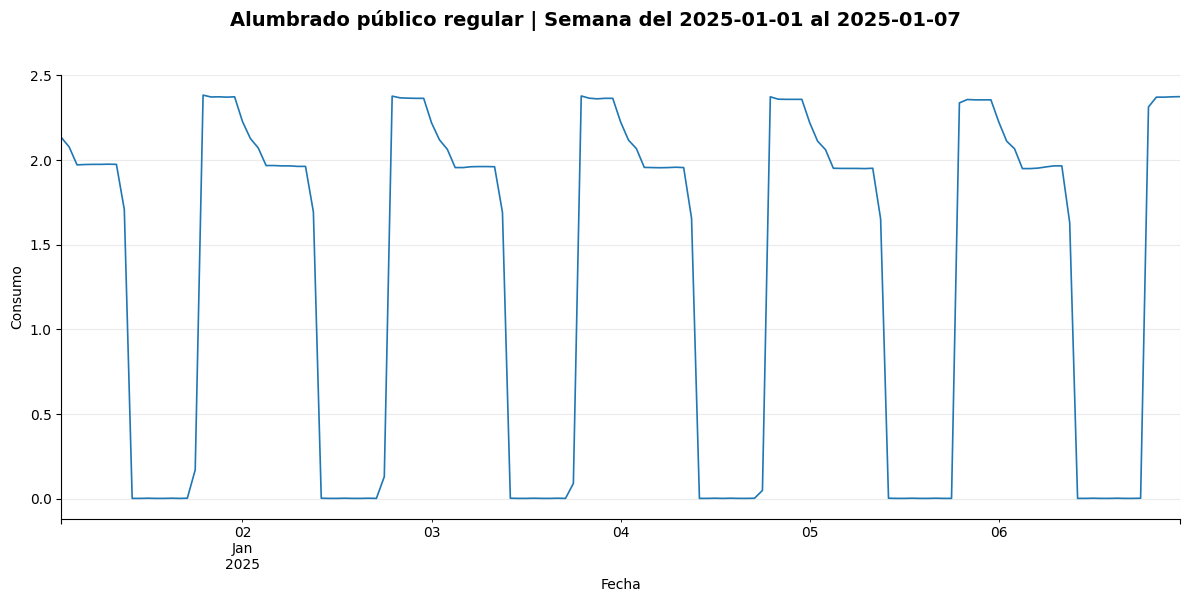

In [6]:
df = pd.read_csv('datasets/alumbrado_1.csv', sep=';', decimal=',')
df.set_index('Fecha', inplace=True)
df.index = pd.to_datetime(df.index, dayfirst=True)

week_start = pd.Timestamp('2025-01-01')
week_end = pd.Timestamp('2025-01-07')
df_week = df.loc[(df.index >= week_start) & (df.index < week_end)]

plot_stacked(
    df_week,
    ['Consumo'],
    f'Alumbrado público regular | Semana del {week_start.date()} al {week_end.date()}',
    sample_size=len(df_week),
    colors=['#1f77b4'],
    figsize=(12, 6),
)

<a id="alumbrado-publico-tipo"></a>
## 2. Alumbrado Público Tipo

Dataset tipo de cuadros de alumbrado público, desde agosto de 2024 hasta marzo de 2026. A diferencia de la serie anterior, estas presentan una estructura y una morfología más irregular, y suponen un nivel intermedio entre esta y los datasets restantes.

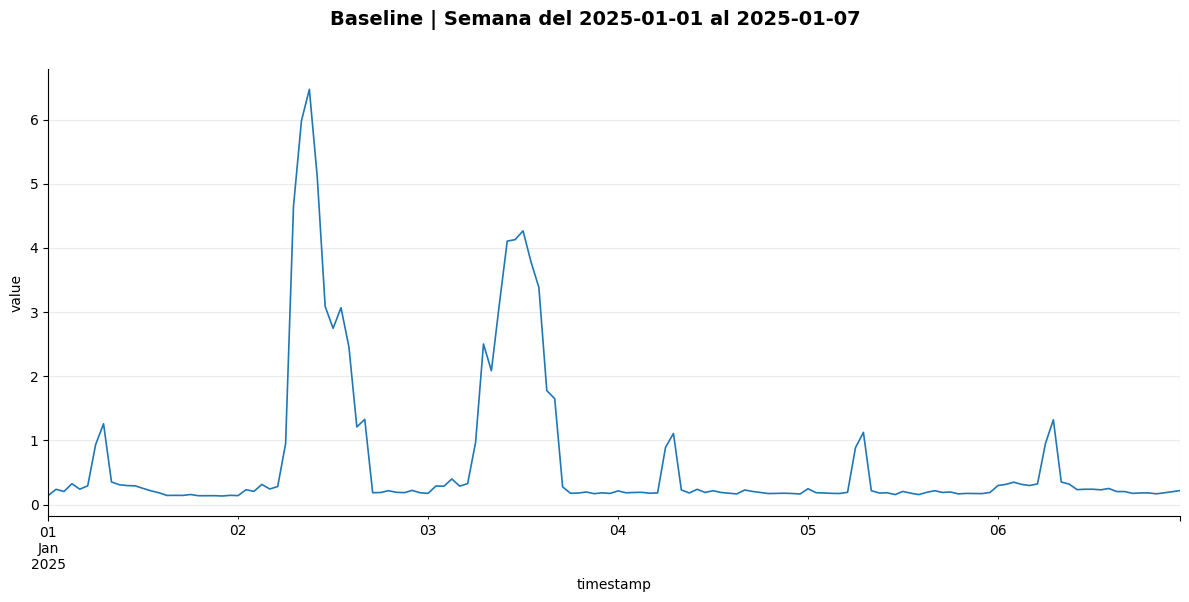

In [5]:
df = pd.read_csv('datasets/cups.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_localize(None)
df = df.set_index('timestamp')
cup = df.iloc[0]['cups']
df = df[df['cups'] == cup].sort_index()

week_start = pd.Timestamp('2025-01-01')
week_end = pd.Timestamp('2025-01-07')
df_week = df.loc[(df.index >= week_start) & (df.index < week_end)]

plot_stacked(
    df_week,
    ['value'],
    f'Baseline | Semana del 2025-01-01 al 2025-01-07',
    sample_size=len(df_week),
    colors=['#1f77b4'],
    figsize=(12, 6),
)

<a id="ett-electricity-transformer-temperature"></a>
## 3. ETT (Electricity Transformer Temperature)

ETT representa variables operativas asociadas a transformadores eléctricos y constituye un benchmark de referencia para forecasting de largo horizonte. Su combinación de tendencia, estacionalidad diaria y patrones periódicos superpuestos lo hace especialmente útil para evaluar modelos sensibles a estacionalidad múltiple.

Fuente: Haoyi Zhou and Shanghang Zhang and Jieqi Peng and Shuai Zhang and Jianxin Li and Hui Xiong and Wancai Zhang, "Informer: Beyond Efficient Transformer for Long Sequence Time-Series Forecasting", *The Thirty-Fifth AAAI Conference on Artificial Intelligence, AAAI 2021*, vol. 35, no. 12, pp. 11106-11115, 2021.

2026-05-21 12:16:55 [INFO]: Start downloading...
2026-05-21 12:16:56 [INFO]: Successfully downloaded data to datasets/electricity_transformer_temperature/ETTm1.csv
2026-05-21 12:16:56 [INFO]: Successfully downloaded data to datasets/electricity_transformer_temperature/ETTm2.csv
2026-05-21 12:16:57 [INFO]: Successfully downloaded data to datasets/electricity_transformer_temperature/ETTh1.csv
2026-05-21 12:16:57 [INFO]: Successfully downloaded data to datasets/electricity_transformer_temperature/ETTh2.csv


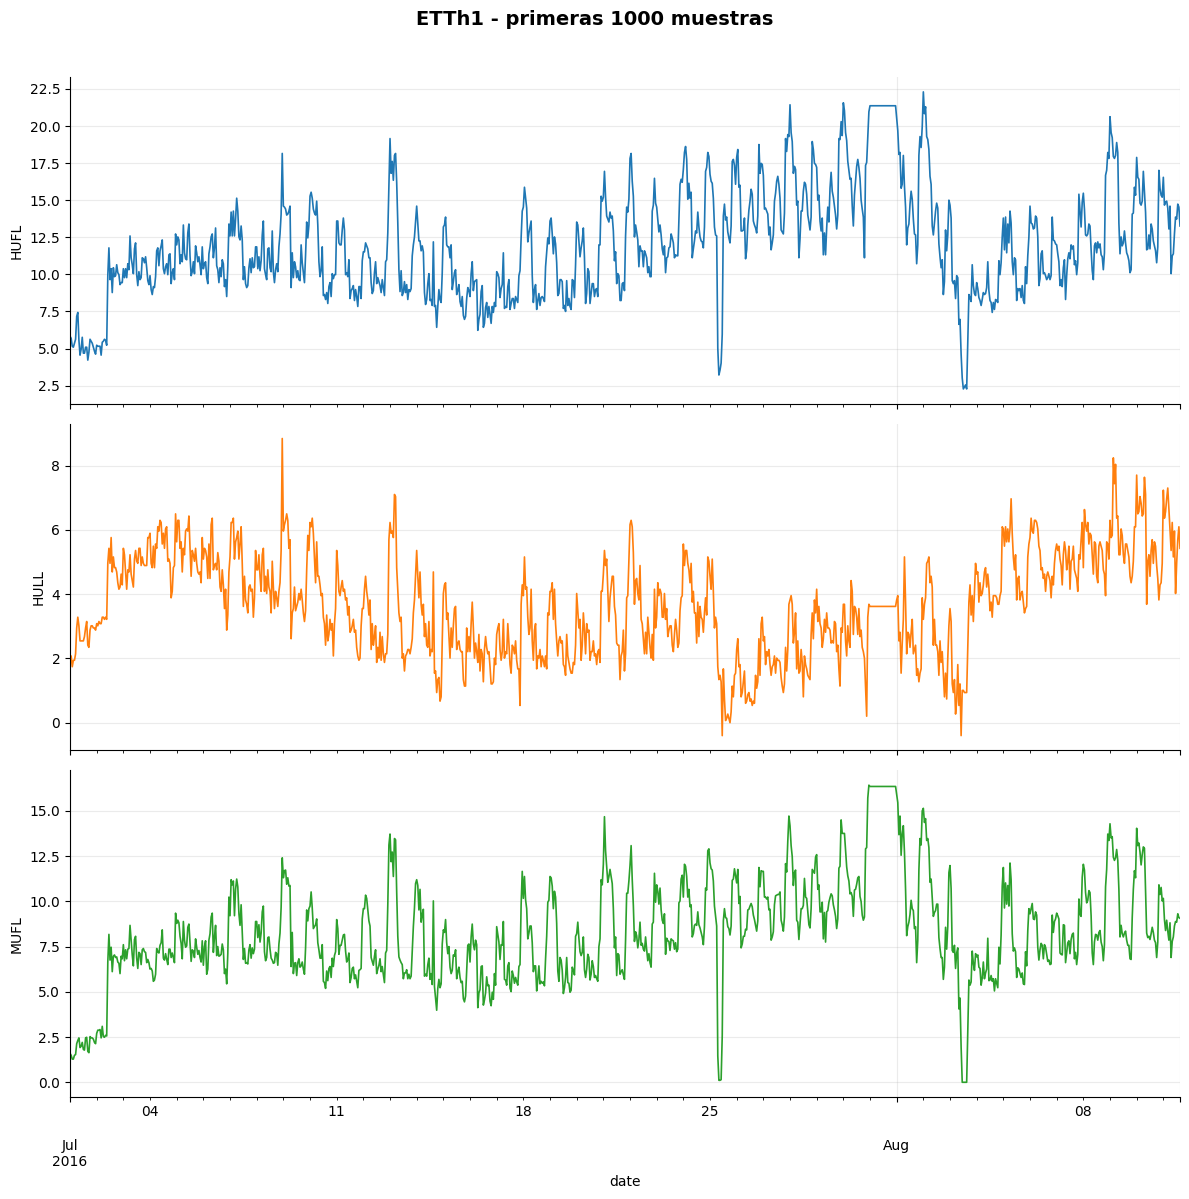

In [8]:
tsdb.download_and_extract('electricity_transformer_temperature', 'datasets/electricity_transformer_temperature/')
df = pd.read_csv('datasets/electricity_transformer_temperature/ETTh1.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

plot_stacked(
    df,
    ['HUFL', 'HULL', 'MUFL'],
    'ETTh1 - primeras 1000 muestras',
    sample_size=1000,
    colors=['#1f77b4', '#ff7f0e', '#2ca02c'],
)

<a id="beijing-multi-site-air-quality"></a>
## 4. Beijing Multi-Site Air-Quality

Este dataset reúne mediciones horarias de contaminantes atmosféricos y variables meteorológicas en varias estaciones de Beijing. Resulta apropiado para procesos multivariantes en presencia de correlación cruzada, variabilidad meteorológica y señales menos regulares.

Fuente: Shuyi Zhang and Bin Guo and Anlan Dong and Jing He and Ziping Xu and Song Xi Chen, "Cautionary tales on air-quality improvement in Beijing", *Proceedings of the Royal Society A: Mathematical, Physical and Engineering Sciences*, vol. 473, 2017.

2026-05-21 12:17:00 [INFO]: Start downloading...
2026-05-21 12:18:18 [INFO]: Successfully downloaded data to C:\Users\msalas\AppData\Local\Temp\tmplrk5p920\PRSA2017_Data_20130301-20170228.zip
2026-05-21 12:18:18 [INFO]: Successfully extracted data to datasets/beijing_multisite_air_quality/


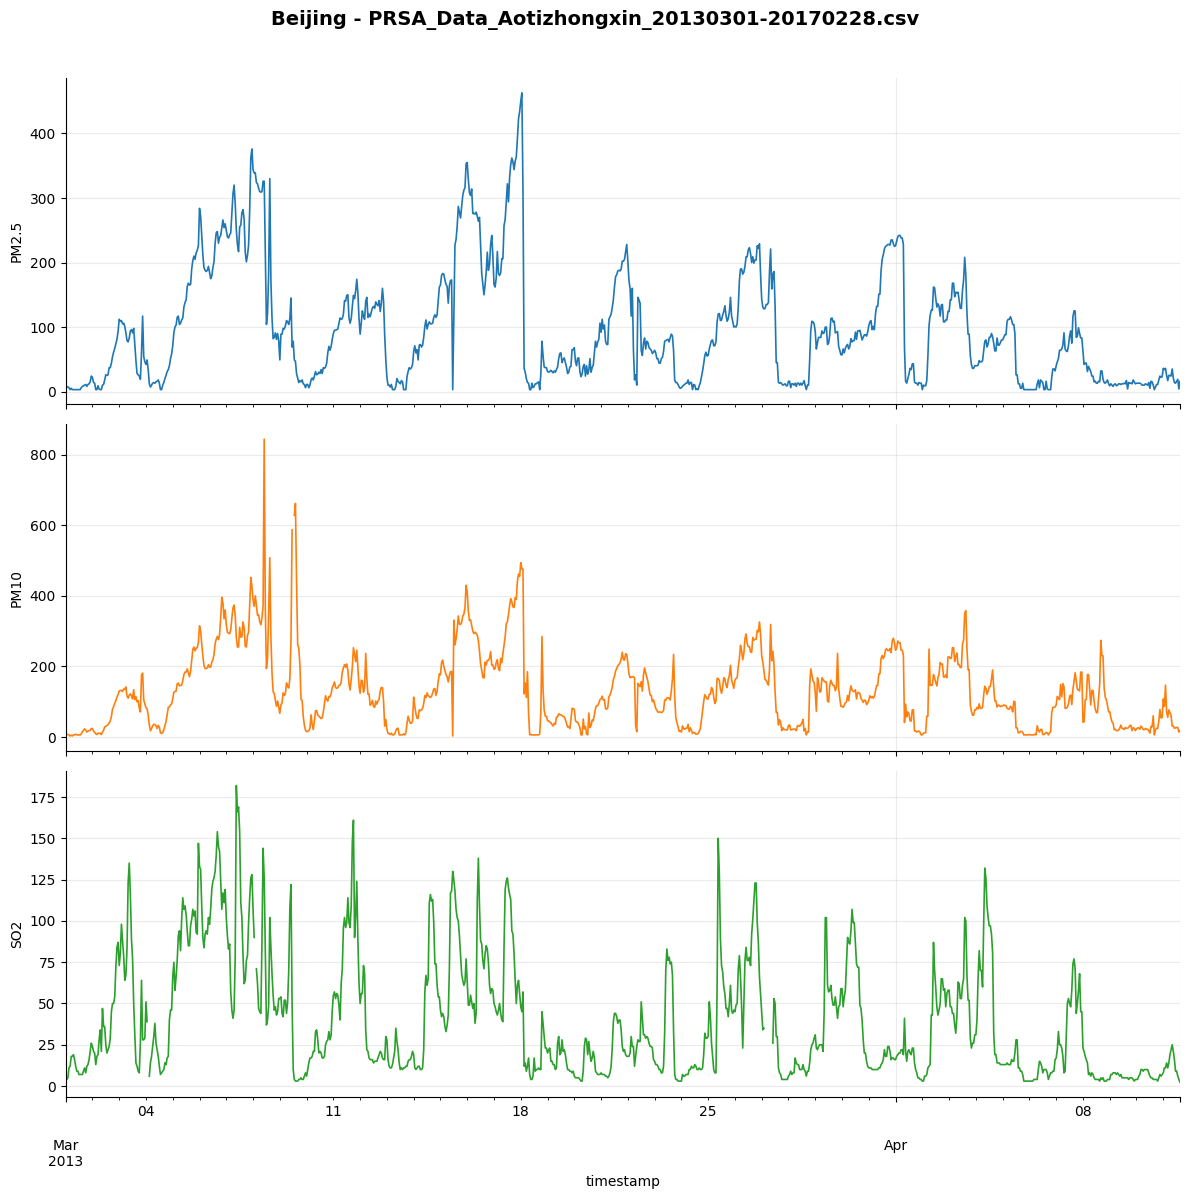

In [9]:
tsdb.download_and_extract('beijing_multisite_air_quality', 'datasets/beijing_multisite_air_quality/')
base_dir = 'datasets/beijing_multisite_air_quality/PRSA_Data_20130301-20170228'
csv_name = None
for name in sorted(os.listdir(base_dir)):
    if name.startswith('PRSA_Data_') and name.endswith('.csv'):
        csv_name = name
        break
if csv_name is None:
    raise FileNotFoundError(f'No se encontro ningun CSV PRSA_Data_* en {base_dir}')

df = pd.read_csv(os.path.join(base_dir, csv_name))
df['timestamp'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.set_index('timestamp')

plot_stacked(
    df,
    ['PM2.5', 'PM10', 'SO2'],
    f'Beijing - {csv_name}',
    sample_size=1000,
    colors=['#1f77b4', '#ff7f0e', '#2ca02c'],
)

<a id="pems-traffic"></a>
## 5. PeMS Traffic

PeMS evalúa la ocupación y el comportamiento del tráfico en autopistas instrumentadas mediante una red extensa de sensores. Es un estándar SOTA para matrices temporales multivariantes con fuerte correlación espacial y resulta especialmente útil para comparar modelos que deben capturar dependencia temporal y relación entre series.

Fuente: https://pems.dot.ca.gov/

2026-05-21 12:45:36 [INFO]: Start downloading...
2026-05-21 12:45:51 [INFO]: Successfully downloaded data to C:\Users\msalas\AppData\Local\Temp\tmp2j52hz0q\traffic.txt.gz
2026-05-21 12:45:52 [INFO]: Successfully extracted data to datasets/pems_traffic/traffic.txt


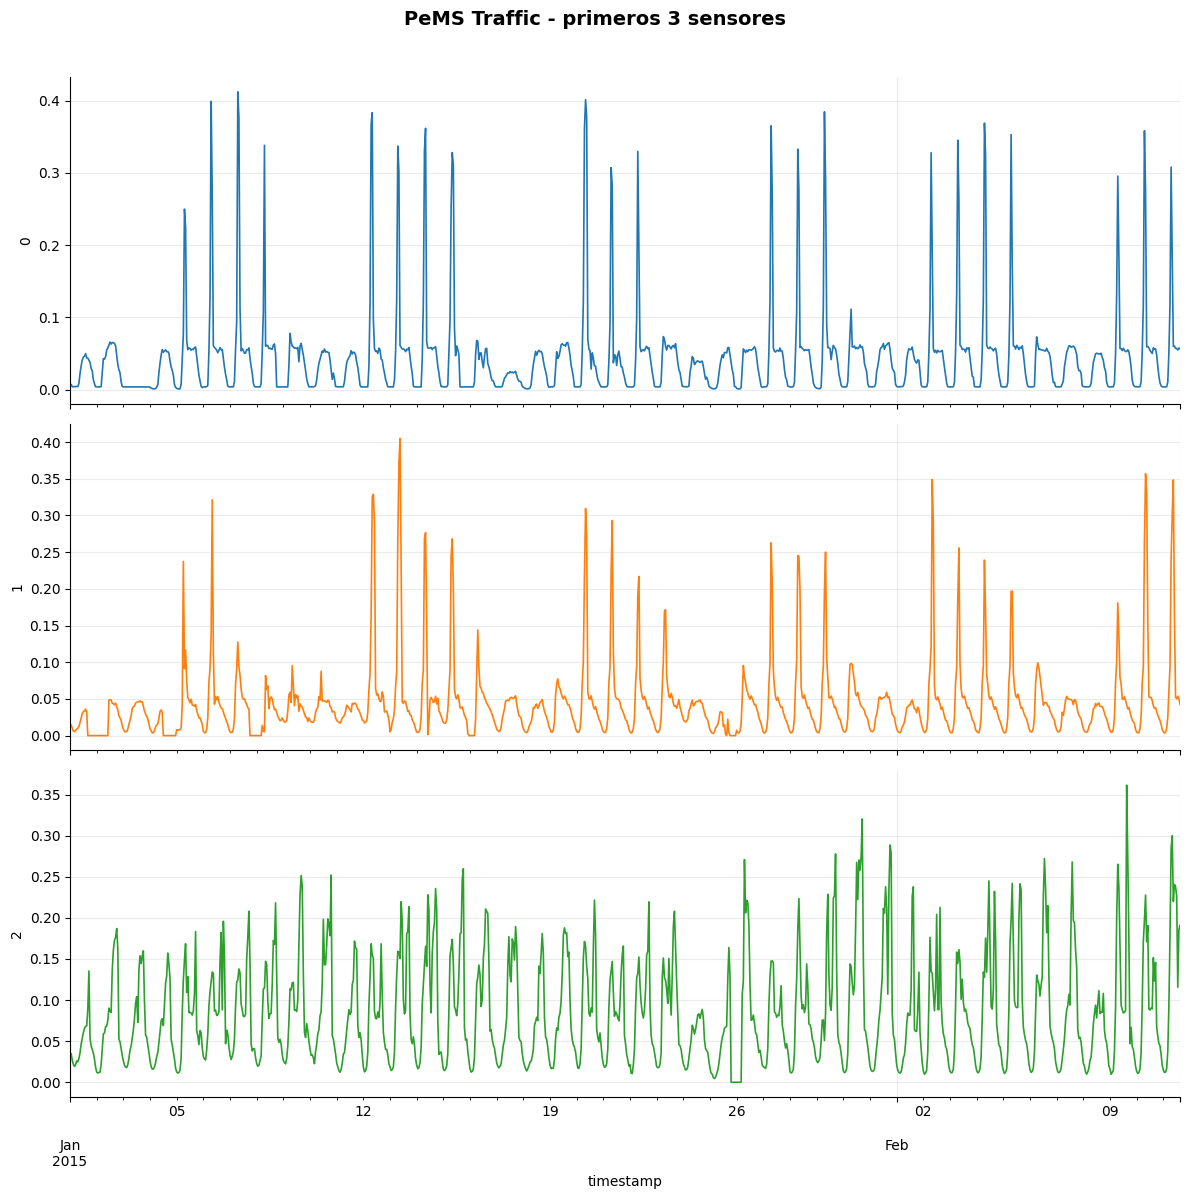

In [11]:
tsdb.download_and_extract('pems_traffic', 'datasets/pems_traffic/')
df = pd.read_csv('datasets/pems_traffic/traffic.txt', header=None)
df.index = pd.date_range('2015-01-01', periods=len(df), freq='h')
df.columns = [str(c) for c in df.columns]

plot_stacked(
    df,
    ['0', '1', '2'],
    'PeMS Traffic - primeros 3 sensores',
    sample_size=1000,
    colors=['#1f77b4', '#ff7f0e', '#2ca02c'],
)